Dataset
[[1.5 2. ]
 [2.  1.5]
 [2.5 2.5]
 [1.8 3. ]
 [7.5 8. ]
 [8.  7.5]
 [8.5 8.5]
 [9.  7.8]]


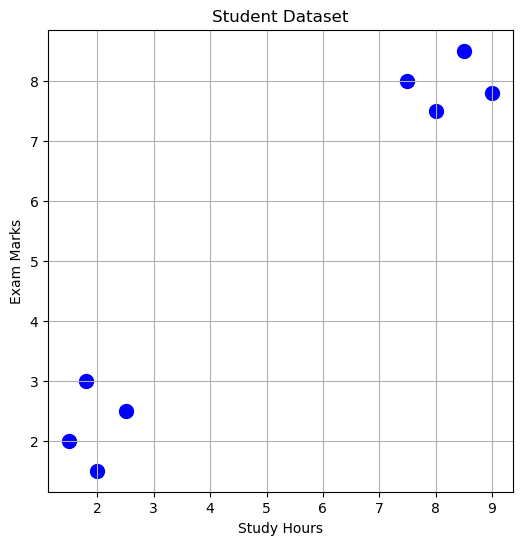

In [9]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1.5, 2.0],
    [2.0, 1.5],
    [2.5, 2.5],
    [1.8, 3.0],
    [7.5, 8.0],
    [8.0, 7.5],
    [8.5, 8.5],
    [9.0, 7.8]
])

print("Dataset")
print(X)

# ---------------------------------------------------------
# STEP 2 : Visualize the Dataset
# ---------------------------------------------------------

plt.figure(figsize=(6,6))

plt.scatter(X[:,0], X[:,1], color="blue", s=100)

plt.xlabel("Study Hours")
plt.ylabel("Exam Marks")
plt.title("Student Dataset")

plt.grid(True)
plt.show()


In [10]:
#initial random centroids

c0 = np.array([2,2])
c1 = np.array([8,8])

print("\nInitial Centroids")
print("Centroid 0 :", c0)
print("Centroid 1 :", c1)

labels = []

for point in X:

    # Distance to Centroid 0
    d0 = np.sqrt((point[0]-c0[0])**2 + (point[1]-c0[1])**2)

    # Distance to Centroid 1
    d1 = np.sqrt((point[0]-c1[0])**2 + (point[1]-c1[1])**2)

    # Assign to nearest centroid
    if d0 < d1:
        labels.append(0)
    else:
        labels.append(1)

labels = np.array(labels)

print("\nCluster Labels")
print(labels)


Initial Centroids
Centroid 0 : [2 2]
Centroid 1 : [8 8]

Cluster Labels
[0 0 0 0 1 1 1 1]


In [12]:
cluster0 = X[labels==0]
cluster1 = X[labels==1]

new_c0 = np.mean(cluster0, axis=0)
new_c1 = np.mean(cluster1, axis=0)

print("\nUpdated Centroids")
print("Centroid 0 :", new_c0)
print("Centroid 1 :", new_c1)


Updated Centroids
Centroid 0 : [1.95 2.25]
Centroid 1 : [8.25 7.95]


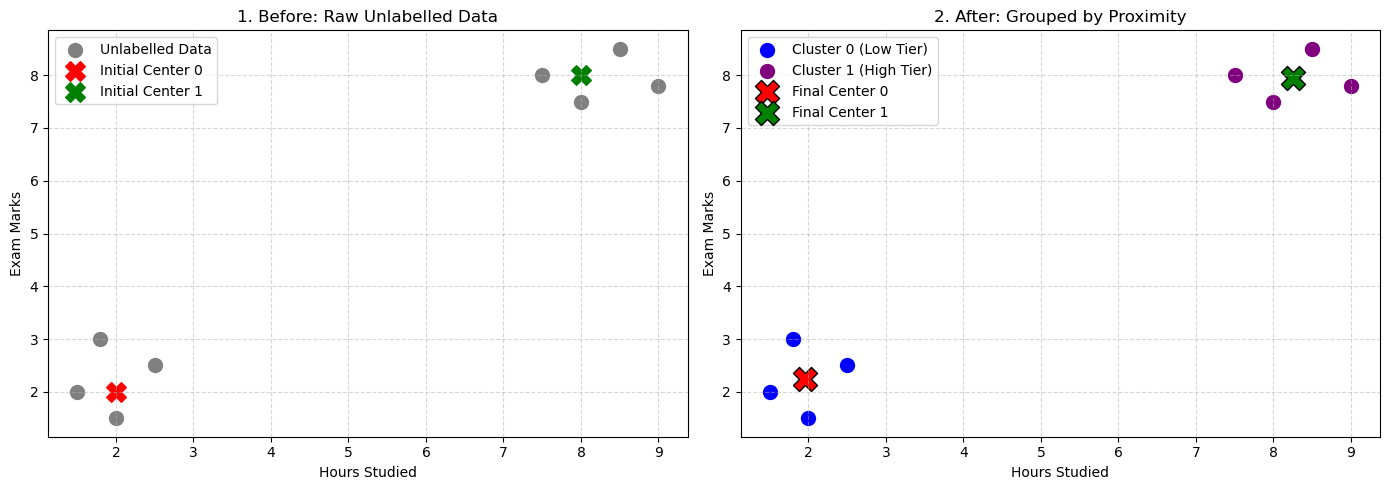

In [13]:
# Create a canvas with 2 plots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X[:, 0], X[:, 1], color='gray', s=100, label='Unlabelled Data')

ax1.scatter(c0[0], c0[1], color='red', marker='X', s=200, label='Initial Center 0')
ax1.scatter(c1[0], c1[1], color='green', marker='X', s=200, label='Initial Center 1')

ax1.set_title("1. Before: Raw Unlabelled Data")
ax1.set_xlabel("Hours Studied")
ax1.set_ylabel("Exam Marks")
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

ax2.scatter(X[labels == 0, 0], X[labels == 0, 1], color='blue', s=100, label='Cluster 0 (Low Tier)')
ax2.scatter(X[labels == 1, 0], X[labels == 1, 1], color='purple', s=100, label='Cluster 1 (High Tier)')

ax2.scatter(new_c0[0], new_c0[1], color='red', marker='X', s=300, edgecolor='black', label='Final Center 0')
ax2.scatter(new_c1[0], new_c1[1], color='green', marker='X', s=300, edgecolor='black', label='Final Center 1')

ax2.set_title("2. After: Grouped by Proximity")
ax2.set_xlabel("Hours Studied")
ax2.set_ylabel("Exam Marks")
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

In [15]:
#new dataa
new_student = np.array([3.0, 3.5])

# Calculate distance from this new data
dist_to_final_c0 = np.sqrt((new_student[0] - new_c0[0])**2 + (new_student[1] - new_c0[1])**2)
dist_to_final_c1 = np.sqrt((new_student[0] - new_c1[0])**2 + (new_student[1] - new_c1[1])**2)

if dist_to_final_c0 < dist_to_final_c1:
    assigned_group = "Cluster 0 (Low Tier)"
else:
    assigned_group = "Cluster 1 (High Tier)"

print(f"\nNew student at {new_student} is closer to Center 0 than Center 1.")
print(f"Result: Automatically categorized into -> {assigned_group}")


New student at [3.  3.5] is closer to Center 0 than Center 1.
Result: Automatically categorized into -> Cluster 0 (Low Tier)
